ML for Robotics Lab-12

Example 1: Algorithm: ε-Greedy

Final Estimated Ratings: [2.96734567 3.20396956 4.49621654]
Number of visits: [ 31.  18. 451.]


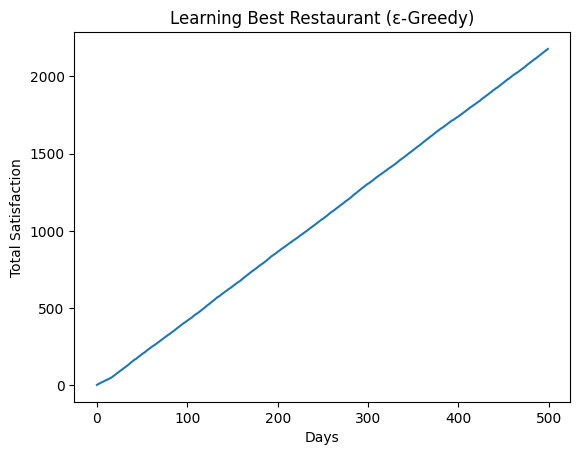

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
restaurants = ["A", "B", "C"]
k = len(restaurants)
true_means = [3.0, 3.5, 4.5]
Q = np.zeros(k)
N = np.zeros(k)
epsilon = 0.1
days = 500
total_reward = 0
rewards = []
choices = []
def get_reward(action):
    return np.random.normal(true_means[action], 0.5)
for day in range(days):
    if np.random.rand() < epsilon:
        action = np.random.randint(k) 
    else:
        action = np.argmax(Q) 
    reward = get_reward(action)
    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]
    total_reward += reward
    rewards.append(total_reward)
    choices.append(action)
print("Final Estimated Ratings:", Q)
print("Number of visits:", N)
plt.plot(rewards)
plt.xlabel("Days")
plt.ylabel("Total Satisfaction")
plt.title("Learning Best Restaurant (ε-Greedy)")
plt.show()

Average rewards over time

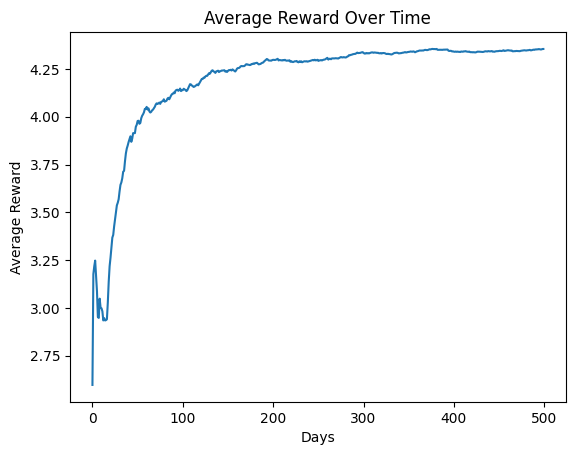

In [2]:
avg_rewards = [rewards[i]/(i+1) for i in range(len(rewards))]
plt.plot(avg_rewards)
plt.xlabel("Days")
plt.ylabel("Average Reward")
plt.title("Average Reward Over Time")
plt.show()

Average rewards over time

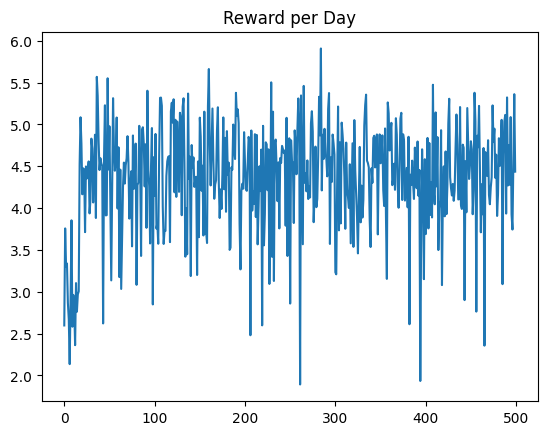

In [3]:
plt.plot([rewards[i] - rewards[i-1] if i>0 else rewards[0] for i in range(len(rewards))])
plt.title("Reward per Day")
plt.show()

Example 2: Value Iteration

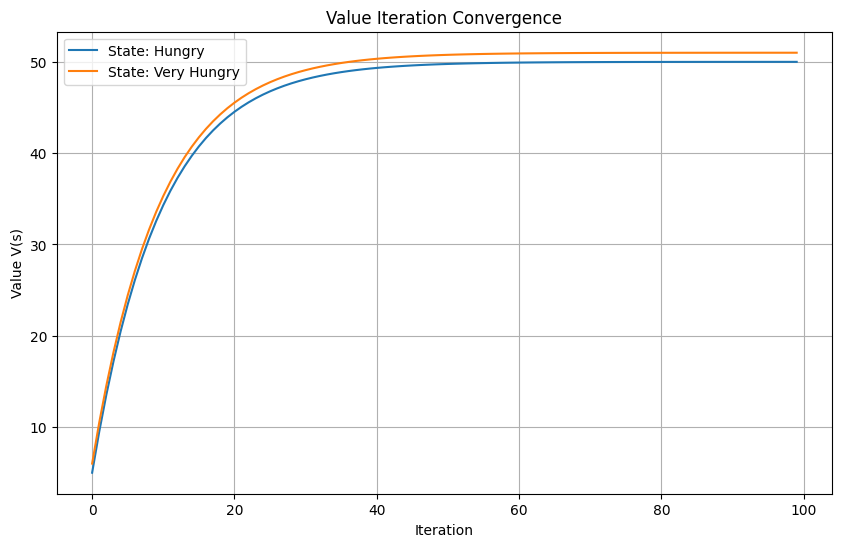

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
states = ["Hungry", "Very Hungry"]
actions = ["A", "B", "C"]
R = np.array([
    [3, 4, 5],
    [2, 3, 6]
])
def get_next_state(s, a):
    return 0
n_states = len(states)
V = np.zeros(n_states)
num_iterations = 100
n_actions = len(actions)
gamma = 0.9
v_history = np.zeros((num_iterations, n_states))
for i in range(num_iterations):
    new_V = np.copy(V)
    for s in range(n_states):
        action_values = []
        for a in range(n_actions):
            next_state = get_next_state(s, a)
            value = R[s][a] + gamma * V[next_state]
            action_values.append(value)
        new_V[s] = max(action_values)
    V = new_V
    v_history[i] = V
plt.figure(figsize=(10, 6))
for s in range(n_states):
    plt.plot(v_history[:, s], label=f'State: {states[s]}')
plt.title("Value Iteration Convergence")
plt.xlabel("Iteration")
plt.ylabel("Value V(s)")
plt.legend()
plt.grid(True)
plt.show()